In [1]:
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
key_size=5
key_file="/mnt/Personal/Projects/Micro_Codes/Python/Crypto/Assignment_1/Text_Files/key_guess.txt"

input_file="/mnt/Personal/Projects/Micro_Codes/Python/Crypto/Assignment_1/Text_Files/encrypted.txt"
output_file="/mnt/Personal/Projects/Micro_Codes/Python/Crypto/Assignment_1/Text_Files/decrypt.txt"

In [3]:
def file_to_string(filename):
    try:
        with open(filename, 'r') as file:
            return file.read()
    except FileNotFoundError:
        raise FileNotFoundError(f"The file '{filename}' was not found")
    except IOError as e:
        raise IOError(f"Error reading file '{filename}': {str(e)}")
    
input_text = file_to_string(input_file)

In [4]:
print(input_text)

print("\n\n",len(input_text)," tokens")

fetoibairfreovlrhudtysmcbpvuoqretoeydnblsgtdtgttrfkohoorhqvluedzxptapegsrkzcsadeyttspkogdeynptxusiooccawmjefoiwhunacnmxarhmdtysfrbpemcllorrfqmgpcjepflgcqlrrifgxqnadqfafgegctcqyrfvbbmdceylxsquaedecfmmqrhmdxjltspdodoecapkymvqrfqbxebelmcpcsikpaohoocdnixuhudbzaznxeemxarhmdxlofrbpcafbpeprfqembpjemfflgzyqysobxnorrfqfmmbcxbypcdqhzcpfskeozvvfiezflkboxiepxlqeudtysnbfehfzflkmxaqhuxvhuedxqifrxbbqokytrsoqttotmrqkayrwlomwzfbjvqdgycwoquifrxfisryjaouignqxignqnzmlxkorudxbbubkymufrfqnqmhrhqdegcwliycwrxgrqczypuxdysudzmuxnyclagxldnoqueqxqfeoblqsnkkbasopnratbatqnflcgbfmuedxglekkbhabkqgufflgtsjrhqcqpazqbqtmzmcadkkaeoykaeufxzlqdegsyecdlqnxldnkkbasoafemntyseyrlluubuhmdpfetkaynfszgpmdbbttkqdodkjmmqxqqhqgxqruqfbhqnfbnadocmafbrhqcbpvuoqreneqpeykfleprljduxdgtmcpfeektloigfrhmlomwzqimvqneynpkkbrqqxpduxdfedgfrhtspgnemostmlicbxebelmcpcsxoxtefrbfafrbqaunpnemuflghoowducqgnodiwttblsgtdecwtsqccxyqf


 876  tokens


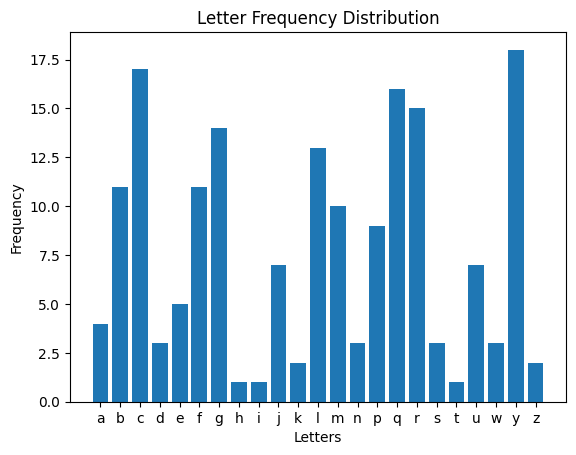

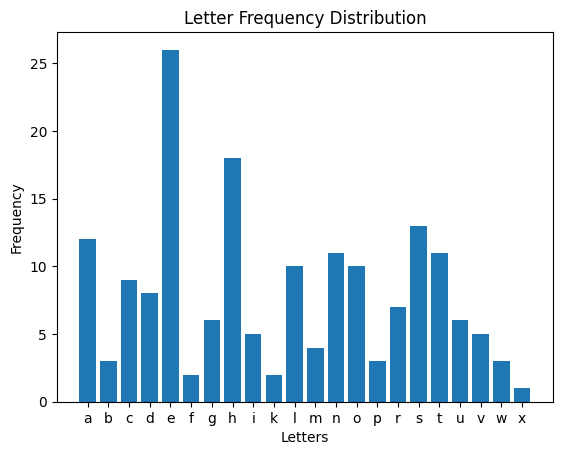

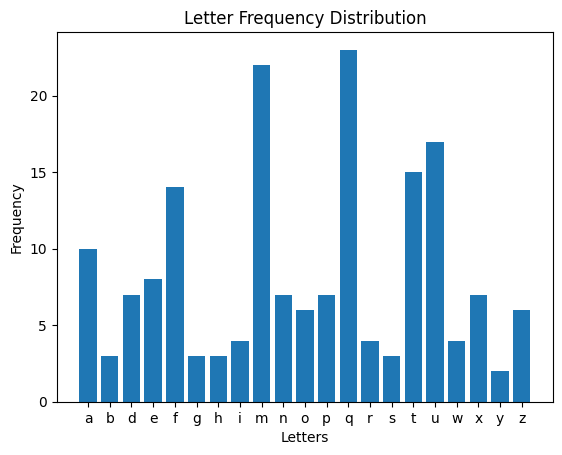

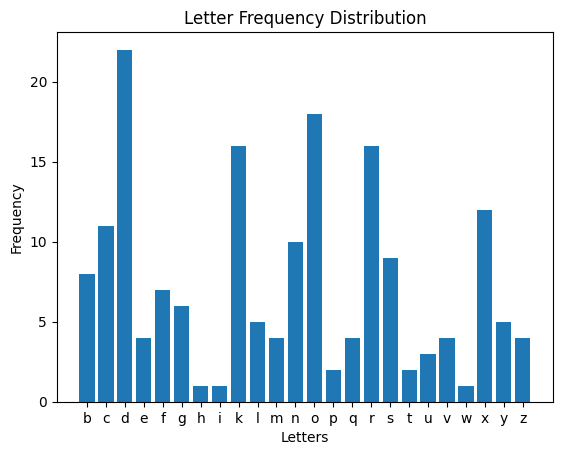

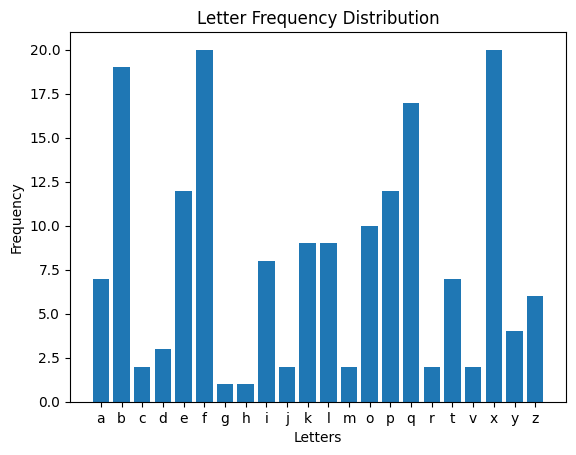

In [5]:
def plot_frequency(text,size,n):
    
    s=""
    
    for i,t in enumerate(text):
        
        if i%size == n :
            s+=t
        
    # Count letter frequencies
    freq = Counter(s)
    letters = sorted(freq.keys())
    counts = [freq[l] for l in letters]
    
    # Create bar plot
    plt.bar(letters, counts)
    plt.title('Letter Frequency Distribution')
    plt.xlabel('Letters')
    plt.ylabel('Frequency')
    plt.show()

plot_frequency(input_text,key_size,0)
plot_frequency(input_text,key_size,1)
plot_frequency(input_text,key_size,2)
plot_frequency(input_text,key_size,3)
plot_frequency(input_text,key_size,4)

In [6]:
key_guess_per_letter =\
            [['e','c'],
            ['e','e'],
            ['e','q'],
            ['t','d'],
            ['e','b']]

guess = []

for k in key_guess_per_letter:
    
    val = (ord(k[1]) - ord(k[0]) + 26 )%26
    guess.append(val)
    
print(guess)

[24, 0, 12, 10, 23]


In [7]:
def generate_guess_key(guess):
    
    s=""
    
    for g in guess:
        
        s+= chr(g+97)
        
    return s
        
guess_key = generate_guess_key(guess)

In [8]:

print(guess_key)

yamkx


In [9]:


def decrypt_text(key,text):
    
    size = len(key)
    out=""
    
    for i,t in enumerate(text):
        
        v1 = ord(key[(i%size)]) - 97
        v2 = ord(t) - 97
        
        dec = (v2-v1 +26 )%26 + 97
        
        # print(v1,t,v2,dec)
        
        out+=chr(dec)
        
    return out

decrypted = decrypt_text(guess_key,input_text)

In [10]:
print(decrypted)

heheldawhiteclothitwasaserviettehehadbroughtwithhimoverthelowerpartofhisfacesothathismouthandjawswerecompletelyhiddenandthatwasthereasonofhismuffledvoicebutitwasnotthatwhichstartledmrshallitwasthefactthatallhisforeheadabovehisblueglasseswascoveredbyawhitebandageandthatanothercoveredhisearsleavingnotascrapofhisfaceexposedexceptingonlyhispinkpeakednoseitwasbrightpinkandshinyjustasithadbeenatfirstheworeadarkbrownvelvetjacketwithahighblacklinenlinedcollarturnedupabouthisneckthethickblackhairescapingasitcouldbelowandbetweenthecrossbandagesprojectedincurioustailsandhornsgivinghimthestrangestappearanceconceivablethismuffledandbandagedheadwassounlikewhatshehadanticipatedthatforamomentshewasrigidhedidnotremovetheserviettebutremainedholdingitasshesawnowwithabrownglovedhandandregardingherwithhisinscrutableblueglassesleavethehathesaidspeakingverydistinctlythroughthewhitecloth


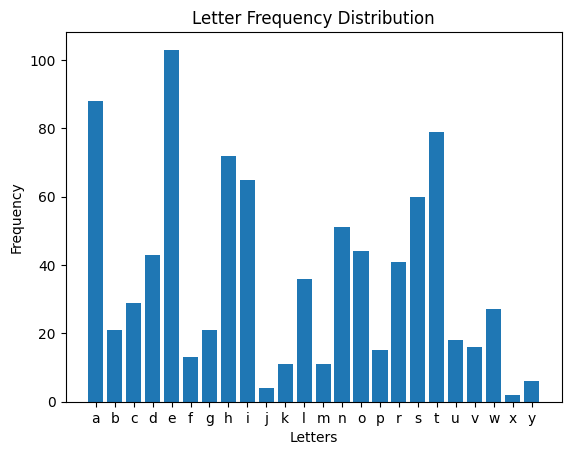

In [14]:
plot_frequency(decrypted,1,0)

In [12]:
def write_file(filename, text):
    try:
        with open(filename, 'w') as file:
            file.write(text)
    except IOError as e:
        print(f"Error writing to file: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

In [13]:
write_file(output_file,decrypted)
write_file(key_file,guess_key)